# Lab 02 · Parte 2 — Relación Jugador → Club → Temporada (R)

En la parte 1 cada club era un **conjunto** de jugadores. Ahora recuperamos la información que se perdió al eliminar duplicados: **en qué temporadas** estuvo cada jugador en cada club.

La relación es un conjunto de tripletas

$$R = \{(\text{jugador}, \text{club}, \text{temporada})\} \subseteq J \times C \times T$$

donde $J$ son los jugadores, $C = \{\text{Atlético}, \text{Barcelona}\}$ y $T$ las 20 temporadas (2004-05 a 2023-24). El club y la temporada no están dentro de los CSV: se extraen del **nombre del archivo** (`atletico_2014-15.csv`).

La representamos de tres formas: **tabla**, **diccionario** (lista en R) y **grafo simple**.

In [1]:
library(ggplot2)

data_dir <- "/home/jovyan/datasets/lab02/futbol_data"
if (!dir.exists(data_dir)) data_dir <- "../../datasets/lab02/futbol_data"

clubes <- c(atletico = "Atlético", barcelona = "Barcelona")

## 1. Construir la relación completa

Por cada archivo se leen sus jugadores y se añaden el club y la temporada que indica su nombre.

In [2]:
leer_temporada <- function(archivo) {
  partes <- regmatches(basename(archivo), regexec("^([a-z]+)_(\\d{4}-\\d{2})\\.csv$", basename(archivo)))[[1]]
  plantilla <- read.csv(archivo, fileEncoding = "UTF-8-BOM")
  data.frame(jugador = trimws(plantilla$jugador),
             club = clubes[[partes[2]]],
             temporada = partes[3])
}

archivos <- list.files(data_dir, pattern = "\\.csv$", full.names = TRUE)
relacion <- do.call(rbind, lapply(archivos, leer_temporada))
stopifnot(!any(duplicated(relacion)))

cat(nrow(relacion), "tripletas (jugador, club, temporada)\n")
cat(length(unique(relacion$jugador)), "jugadores ·", length(unique(relacion$club)), "clubes ·",
    length(unique(relacion$temporada)), "temporadas\n")

551 tripletas (jugador, club, temporada)
108 jugadores · 2 clubes · 20 temporadas


## 2. Tres representaciones

### 2a. Tabla

Cada fila es un elemento de la relación. Primeras filas y un ejemplo con los 3 jugadores que pasaron por ambos clubes:

In [3]:
head(relacion, 10)

,jugador,club,temporada
,<chr>,<chr>,<chr>
1,Antonio López,Atlético,2004-05
2,Colsa,Atlético,2004-05
3,Fernando Torres,Atlético,2004-05
4,García Calvo,Atlético,2004-05
5,Ibagaza,Atlético,2004-05
6,Jorge Larena,Atlético,2004-05
7,Juan Valera,Atlético,2004-05
8,Juan Velasco,Atlético,2004-05
9,Leo Franco,Atlético,2004-05


In [4]:
compartidos <- c("Antoine Griezmann", "David Villa", "João Félix")
ejemplo <- relacion[relacion$jugador %in% compartidos, ]
ejemplo <- ejemplo[order(ejemplo$jugador, ejemplo$temporada), ]
rownames(ejemplo) <- NULL
ejemplo

jugador,club,temporada
<chr>,<chr>,<chr>
Antoine Griezmann,Atlético,2014-15
Antoine Griezmann,Atlético,2015-16
Antoine Griezmann,Atlético,2016-17
Antoine Griezmann,Atlético,2017-18
Antoine Griezmann,Atlético,2018-19
Antoine Griezmann,Barcelona,2019-20
Antoine Griezmann,Barcelona,2020-21
Antoine Griezmann,Atlético,2021-22
Antoine Griezmann,Atlético,2022-23


Vista resumida de la tabla: temporadas de cada jugador en cada club.

In [5]:
tabla_resumen <- aggregate(temporada ~ jugador + club, data = relacion,
                           FUN = function(t) c(temporadas = length(t), primera = min(t), ultima = max(t)))
tabla_resumen <- do.call(data.frame, tabla_resumen)
names(tabla_resumen) <- c("jugador", "club", "temporadas", "primera", "ultima")
tabla_resumen$temporadas <- as.integer(tabla_resumen$temporadas)
head(tabla_resumen[order(-tabla_resumen$temporadas), ], 10)

,jugador,club,temporadas,primera,ultima
,<chr>,<chr>,<int>,<chr>,<chr>
88,Lionel Messi,Barcelona,17,2004-05,2020-21
61,Andrés Iniesta,Barcelona,15,2004-05,2018-19
104,Sergio Busquets,Barcelona,15,2008-09,2022-23
76,Gerard Piqué,Barcelona,14,2008-09,2021-22
29,Koke Resurrección,Atlético,13,2011-12,2023-24
49,Saúl Ñíguez,Atlético,11,2013-14,2023-24
64,Carles Puyol,Barcelona,11,2004-05,2014-15
84,Jordi Alba,Barcelona,11,2012-13,2022-23
108,Víctor Valdés,Barcelona,11,2004-05,2014-15


### 2b. Lista (equivalente al diccionario)

Una lista con nombre `jugador → club → temporadas`: `split()` agrupa primero por jugador y después por club.

In [6]:
lista <- lapply(split(relacion, relacion$jugador),
                function(d) lapply(split(d$temporada, d$club), sort))

cat(length(lista), "jugadores en la lista\n\n")
str(lista[c(compartidos, "Lionel Messi")])

108 jugadores en la lista

List of 4
 $ Antoine Griezmann:List of 2
  ..$ Atlético : chr [1:8] "2014-15" "2015-16" "2016-17" "2017-18" ...
  ..$ Barcelona: chr [1:2] "2019-20" "2020-21"
 $ David Villa      :List of 2
  ..$ Atlético : chr [1:2] "2013-14" "2014-15"
  ..$ Barcelona: chr [1:3] "2010-11" "2011-12" "2012-13"
 $ João Félix       :List of 2
  ..$ Atlético : chr [1:4] "2019-20" "2020-21" "2021-22" "2022-23"
  ..$ Barcelona: chr "2023-24"
 $ Lionel Messi     :List of 1
  ..$ Barcelona: chr [1:17] "2004-05" "2005-06" "2006-07" "2007-08" ...


### 2c. Grafo simple

Un **grafo simple** no tiene aristas repetidas ni bucles. Para que lo sea, la relación ternaria se proyecta en un grafo **bipartito**:

- **Nodos:** los 108 jugadores y los 2 clubes.
- **Aristas:** una única arista jugador–club si el jugador estuvo en ese club, aunque fuera varias temporadas.
- **Peso de la arista:** el número de temporadas. Así la tercera componente (temporada) no se pierde.

En el dibujo, los jugadores exclusivos de cada club rodean a su club y los 3 compartidos quedan en el centro, conectados a ambos. Solo se rotulan los compartidos y los que tienen 10 temporadas o más.


Sin `igraph` en la imagen, el grafo se representa con su **lista de aristas** y su **matriz de incidencia**, y se dibuja con `ggplot2`.

In [7]:
aristas <- aggregate(temporada ~ jugador + club, data = relacion, FUN = length)
names(aristas)[3] <- "temporadas"

grado <- table(aristas$jugador)
nodos <- c(unname(clubes), sort(unique(relacion$jugador)))

cat("Nodos:", length(nodos), "· Aristas:", nrow(aristas), "\n")
cat("¿Grafo simple (sin aristas repetidas)?", !any(duplicated(aristas[, c("jugador", "club")])), "\n")
cat("Jugadores conectados a los dos clubes:", names(grado[grado == 2]), sep = "\n  ")

# Matriz de incidencia jugador x club (peso = temporadas)
incidencia <- xtabs(temporadas ~ jugador + club, data = aristas)
incidencia[compartidos, ]

Nodos: 110 · Aristas: 111 
¿Grafo simple (sin aristas repetidas)? TRUE 
Jugadores conectados a los dos clubes:
  Antoine Griezmann
  David Villa
  João Félix


                   club
jugador             Atlético Barcelona
  Antoine Griezmann        8         2
  David Villa              2         3
  João Félix               4         1

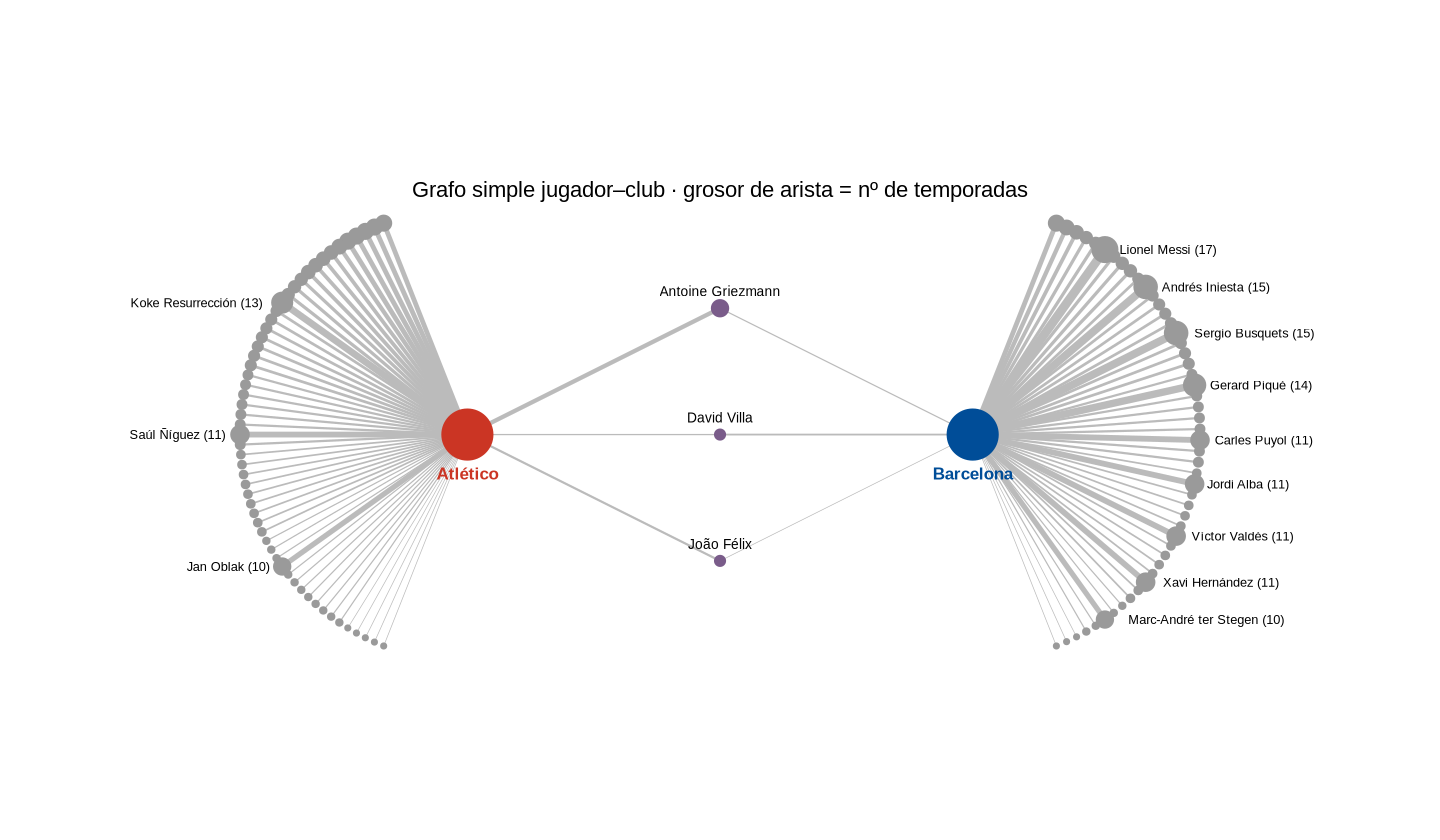

In [8]:
options(repr.plot.width = 12, repr.plot.height = 7)

centro_club <- c("Atlético" = -1, "Barcelona" = 1)
temporadas_jugador <- tapply(relacion$temporada, relacion$jugador, length)

pos <- data.frame(nodo = unname(clubes), x = c(-1, 1), y = 0, tipo = "club", stringsAsFactors = FALSE)
compartidos_ord <- sort(names(grado[grado == 2]))
pos <- rbind(pos, data.frame(nodo = compartidos_ord, x = 0, y = 0.5 - 0.5 * (seq_along(compartidos_ord) - 1),
                             tipo = "compartido"))
for (club in names(centro_club)) {
  lado <- centro_club[[club]]
  excl <- aristas[aristas$club == club & grado[aristas$jugador] == 1, ]
  excl <- excl[order(-excl$temporadas), ]
  # Los destacados se reparten a lo largo del abanico para que sus etiquetas no se solapen
  destacados <- excl[excl$temporadas >= 10, ]
  orden <- excl[excl$temporadas < 10, ]
  huecos <- round(seq(1, nrow(excl), length.out = nrow(destacados) + 2))[-c(1, nrow(destacados) + 2)]
  for (i in seq_len(nrow(destacados))) {
    orden <- rbind(orden[seq_len(huecos[i] - 1), ], destacados[i, ], orden[-seq_len(huecos[i] - 1), ])
  }
  excl <- orden
  a <- seq(pi * 0.62, pi * 1.38, length.out = nrow(excl))
  pos <- rbind(pos, data.frame(nodo = excl$jugador, x = lado - lado * 0.9 * cos(a), y = 0.9 * sin(a),
                               tipo = "exclusivo"))
}

segmentos <- merge(aristas, pos[, c("nodo", "x", "y")], by.x = "jugador", by.y = "nodo")
segmentos <- merge(segmentos, pos[, c("nodo", "x", "y")], by.x = "club", by.y = "nodo", suffixes = c("", "_club"))

pos$tam <- ifelse(pos$tipo == "club", 14, 1 + 0.35 * temporadas_jugador[pos$nodo])
pos$color <- ifelse(pos$nodo == "Atlético", "#CB3524", ifelse(pos$nodo == "Barcelona", "#004D98",
                    ifelse(pos$tipo == "compartido", "#7a5c8a", "#9a9a9a")))
destacados_pos <- pos[pos$tipo == "exclusivo" & temporadas_jugador[pos$nodo] >= 10, ]
destacados_pos$texto <- sprintf("%s (%d)", destacados_pos$nodo, temporadas_jugador[destacados_pos$nodo])
destacados_pos$hjust <- ifelse(destacados_pos$x > 0, -0.15, 1.15)

ggplot() +
  geom_segment(data = segmentos, aes(x = x, y = y, xend = x_club, yend = y_club, linewidth = temporadas),
               colour = "#bbbbbb") +
  geom_point(data = pos, aes(x, y, size = tam), colour = pos$color) +
  geom_text(data = pos[pos$tipo == "club", ], aes(x, y - 0.13, label = nodo), colour = pos$color[pos$tipo == "club"],
            size = 3.6, fontface = "bold", vjust = 1) +
  geom_text(data = pos[pos$tipo == "compartido", ], aes(x, y, label = nodo), size = 2.9, vjust = -1.2) +
  geom_text(data = destacados_pos, aes(x, y, label = texto, hjust = hjust), size = 2.7) +
  scale_x_continuous(expand = expansion(mult = 0.25)) +
  scale_linewidth(range = c(0.2, 2.5), guide = "none") +
  scale_size_identity() +
  coord_equal() +
  labs(title = "Grafo simple jugador–club · grosor de arista = nº de temporadas") +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5))

## 3. Preguntas

### ¿Qué jugadores tienen más temporadas?

Se cuentan las temporadas de cada jugador sumando ambos clubes.

In [9]:
por_jugador <- data.frame(
  jugador = names(temporadas_jugador),
  temporadas = as.integer(temporadas_jugador),
  clubes = sapply(lista[names(temporadas_jugador)], function(l) paste(sort(names(l)), collapse = " + "))
)
por_jugador <- por_jugador[order(-por_jugador$temporadas), ]
rownames(por_jugador) <- NULL
head(por_jugador, 10)

,jugador,temporadas,clubes
,<chr>,<int>,<chr>
1,Lionel Messi,17,Barcelona
2,Andrés Iniesta,15,Barcelona
3,Sergio Busquets,15,Barcelona
4,Gerard Piqué,14,Barcelona
5,Koke Resurrección,13,Atlético
6,Carles Puyol,11,Barcelona
7,Jordi Alba,11,Barcelona
8,Saúl Ñíguez,11,Atlético
9,Víctor Valdés,11,Barcelona


In [10]:
maximo <- max(por_jugador$temporadas)
cat("Más temporadas:", paste(por_jugador$jugador[por_jugador$temporadas == maximo], collapse = ", "),
    "con", maximo, "\n")

Más temporadas: Lionel Messi con 17 


### ¿Qué relación es más densa: Club A o Club B?

Se define la **densidad** de la relación de cada club como la proporción de la matriz jugador × temporada que está ocupada:

$$\text{densidad}(c) = \frac{|R_c|}{|J_c| \cdot |T|}$$

Es la densidad del grafo bipartito jugador–temporada de ese club: 1 significaría que todos sus jugadores estuvieron las 20 temporadas. Una densidad mayor indica una **plantilla más estable**, con jugadores que permanecen más años.

In [11]:
total_temporadas <- length(unique(relacion$temporada))
densidad <- data.frame(
  pares = as.integer(table(relacion$club)),
  jugadores = as.integer(tapply(relacion$jugador, relacion$club, function(j) length(unique(j)))),
  row.names = names(table(relacion$club))
)
densidad$temporadas <- total_temporadas
densidad$densidad <- densidad$pares / (densidad$jugadores * densidad$temporadas)
densidad$temporadas_por_jugador <- densidad$pares / densidad$jugadores
round(densidad, 3)

,pares,jugadores,temporadas,densidad,temporadas_por_jugador
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Atlético,264,58,20,0.228,4.552
Barcelona,287,53,20,0.271,5.415


In [12]:
mas_densa <- rownames(densidad)[which.max(densidad$densidad)]
cat(sprintf("Relación más densa: %s (%.3f)\n", mas_densa, max(densidad$densidad)))

Relación más densa: Barcelona (0.271)


## Conclusiones

- La relación completa tiene **551 tripletas** (264 del Atlético y 287 del Barcelona), sin duplicados.
- **Lionel Messi** es el jugador con más temporadas (**17**, todas en el Barcelona), seguido de **Andrés Iniesta** y **Sergio Busquets** (15) y **Gerard Piqué** (14).
- El grafo simple tiene **110 nodos** (108 jugadores y 2 clubes) y **111 aristas**: 108 jugadores, más una arista extra por cada uno de los 3 que jugaron en ambos clubes.
- El **Barcelona** tiene la relación más densa (**0,271** frente a **0,228**): sus jugadores permanecen de media **5,42** temporadas, frente a **4,55** en el Atlético. Es decir, con menos jugadores distintos (53 frente a 58) ha cubierto más plazas de plantilla.